In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


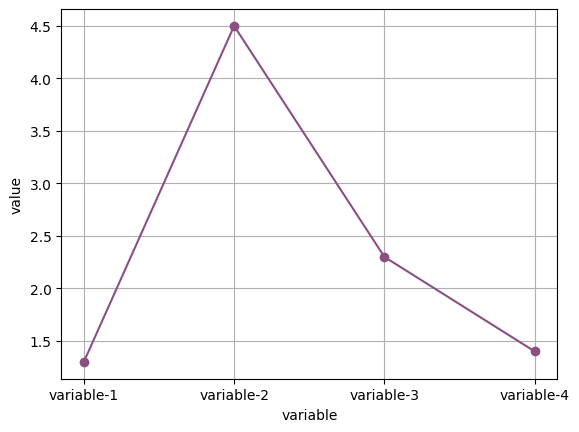

In [32]:
#@title Create graph with json file
import matplotlib.pyplot as plt
import json
#{
#"variable-1":1.0,
#"variable-2":4.5,
#"variable-3":2.3,
#"variable-4":1.4,
#"variable-1":1.3
#}

dictionary = json.load(open('/content/drive/My Drive/3_1.json','r'))
xAxis = [key for key, value in dictionary.items()]
yAxis = [value for key, value in dictionary.items()]
plt.grid(True)

plt.plot(xAxis,yAxis, color='#8a5082',marker='o') # (. , o v > < ^)
plt.xlabel('variable')
plt.ylabel('value')
plt.show()

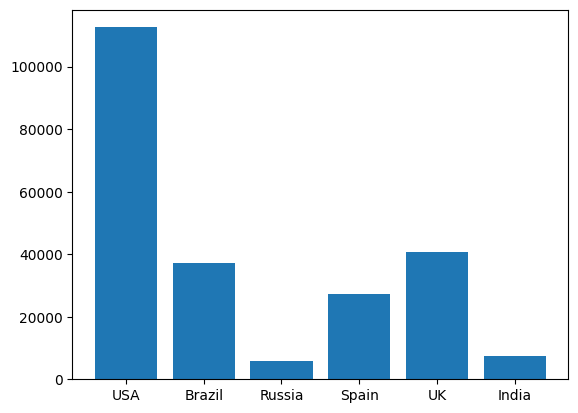

In [ ]:
#@title Bar graph
import matplotlib.pyplot as plt

countries = ['USA','Brazil','Russia','Spain','UK','India']
totalDeaths = [112596,37312,5971,27136,40597,7449]
plt.bar(countries,totalDeaths)
plt.show()

In [ ]:
#@title Pandas(1) - table
import pandas as pd

a = [1,7,2]
myvar = pd.Series(a)
print(myvar)
print(myvar[0])

0    1
1    7
2    2
dtype: int64
1


In [ ]:
#@title Pandas(2) - DataFrame
import pandas as pd

data = {
    "calories":[420,380,390],
    "duration":[50,40,45]
}

df = pd.DataFrame(data,index=["day1","day2","day3"])
print(df)
print("-------------")
# locate the named index
print(df.loc["day2"])

      calories  duration
day1       420        50
day2       380        40
day3       390        45
-------------
calories    380
duration     40
Name: day2, dtype: int64


In [ ]:
#@title Pandas(3) - DataFrame with JSON
import pandas as pd

#data = {
#    "cars":["BMW","SEAT","Ford"],
#    "passings":[3,7,2]
#}

df = pd.read_json('/content/drive/My Drive/3_2.json')
print(df)



   cars  passings
0   BMW         3
1  SEAT         7
2  Ford         2


In [ ]:
#@title Pandas(4) - Conditioned DataFrame
import pandas as pd

data = {
    "cars":["BMW","SEAT","Ford"],
    "passings":[3,7,2]
}

df = pd.DataFrame(data)
morePassing = df[df['passings']>2]
print(morePassing)




   cars  passings
0   BMW         3
1  SEAT         7


In [ ]:
#@title importing vehicle data
import requests
import pandas as pd
url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=053cea08-09bc-40ec-8f7a-156f0677aff3'
pd.set_option("display.max_columns",None)

response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
data_df = pd.DataFrame(data['result']['records'])
data_df.head() # show only first 5 rows

,_id,mispar_rechev,tozeret_cd,sug_degem,tozeret_nm,degem_cd,degem_nm,ramat_gimur,ramat_eivzur_betihuty,kvutzat_zihum,shnat_yitzur,degem_manoa,mivchan_acharon_dt,tokef_dt,baalut,misgeret,tzeva_cd,tzeva_rechev,zmig_kidmi,zmig_ahori,sug_delek_nm,horaat_rishum,moed_aliya_lakvish,kinuy_mishari
0,1,1000028,735,P,פורשה גרמניה,124,95B,,NaN,15.0,2016,CTBA,2026-03-11,2027-03-15,פרטי,WP1ZZZ95ZGLB70121,80,שנהב לבן,235/60/18,255/55/18,דיזל,160387.0,2016-3,MACAN S DIESEL
1,2,1000031,593,P,מרצדס בנץ גרמנ,265,205.045,VISION,1.0,15.0,2014,M274,2024-07-02,2025-06-14,פרטי,WDD2050451F020392,36,כחול מטל,225/40R19,255/35R19,בנזין,140358.0,2014-6,C250
2,3,1000032,830,P,מרצדס בנץ ארהב,25,166.873,PREMIUM,2.0,15.0,2014,M278,2026-01-23,2027-02-04,פרטי,WDC1668731A340161,10,שחור,295/40R21,295/40R21,בנזין,140154.0,2014-2,GL500 4MATIC
3,4,1000037,404,P,לקסוס יפן,60,AGZ15L-AWTLTW,PREMIUM,NaN,15.0,2016,8AR,2026-02-01,2027-02-28,פרטי,JTJBARBZ202065519,80,שנהב לבן,225/60R18,225/60R18,בנזין,160244.0,2016-2,LEXUS NX200T
4,5,1000033,74,P,אלפא רומיאו,77,940FXR11,QV VOLANTE,NaN,15.0,2015,940B2000,2025-06-05,2026-06-10,פרטי,ZAR94000007383291,50,אדום,225/40ZR18,225/40ZR18,בנזין,150057.0,2015-6,ALFA GIULIETTA


In [ ]:
#@title importing conditioned vehicle data
import requests
import pandas as pd
from ipywidgets import widgets,VBox,Output
from IPython.display import display
url = 'https://data.gov.il/api/3/action/datastore_search?resource_id=053cea08-09bc-40ec-8f7a-156f0677aff3'
pd.set_option("display.max_columns",None)

response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
data_df = pd.DataFrame(data['result']['records'])
data_df.head()
output_area = Output() # clears display, without it we would see first 5 rows

tozeret_nm_dropdown = widgets.Dropdown(
    options=[''] + sorted(data_df['tozeret_nm'].unique().tolist()),
    description='Tozeret:',
    style={'description_width':'initial'}
)

kinuy_mishari_dropdown = widgets.Dropdown(
    options=[''],
    description='Kinuy Mishari:',
    style={'description_width':'initial'}
)

# update second dropdown based on the selection of the first
def update_kinuy_mishari_options(change):
  if change['new']:
    filtered_values = data_df[data_df['tozeret_nm']==change['new']]['kinuy_mishari'].unique()
    kinuy_mishari_dropdown.options = [''] + sorted(filtered_values)
  else:
    kinuy_mishari_dropdown.options = ['']

# update output with total records and unique 'ramat gimur'
def update_output(change=None):
  output_area.clear_output()
  selected_tozeret = tozeret_nm_dropdown.value
  selected_kinuy = kinuy_mishari_dropdown.value

  if selected_tozeret and selected_kinuy:
    filtered_df = data_df[
        (data_df['tozeret_nm']==selected_tozeret) & (data_df['kinuy_mishari']==selected_kinuy)
    ]
    total_records = len(filtered_df)
    unique_ramat_gimur = filtered_df['ramat_gimur'].unique()

    with output_area:
      print(f"Total Records: {total_records}")
      print(f"Unqiue Ramat Gimur: {', '.join(unique_ramat_gimur) if len(unique_ramat_gimur) > 0 else 'None'}")
  else:
    with output_area:
      print("Please select valid options for both dropdowns!")

# observe changes in dropdown values
tozeret_nm_dropdown.observe(update_kinuy_mishari_options,names='value')
kinuy_mishari_dropdown.observe(update_output,names='value')

# show widgets and output
display(VBox([tozeret_nm_dropdown,kinuy_mishari_dropdown,output_area]))



In [ ]:
#@title Plotly(1) Visual representation - Scatter Matrix
import pandas as pd
import plotly.express as px

data = {
    "Country": ["Germany", "France", "Italy", "Spain", "United Kingdom"],
    "GDP": [3.8, 2.7, 1.9, 1.4, 2.1],
    "Population": [83, 67, 60, 47, 66],
    "Vehicles Fleet": [50, 35, 40, 30, 45]
}

df = pd.DataFrame(data)
fig = px.scatter_matrix(df,
                        dimensions=["GDP","Population","Vehicles Fleet"],
                        color="Country",
                        title="Scatter Matrix: Country GDP, Population, Vehicle Fleet in Europe"
                      )
fig.show()

In [ ]:
#@title Plotly(2) Visual representation - Graph
import pandas as pd
from plotly.offline import iplot
import plotly.graph_objs as go

data = [
    go.Contour(
        z=[[10, 10.625, 12.5, 15.625, 20],
           [5.625, 6.25, 8.125, 11.25, 15.625],
           [2.5, 3.125, 5., 8.125, 12.5],
           [0.625, 1.25, 3.125, 6.25, 10.625],
           [0, 0.625, 2.5, 5.625, 10]]
    )
]
iplot(data)





In [ ]:
#@title Plotly(3) Visual representation - Graph
import plotly.graph_objects as go
import datetime
import numpy as np

np.random.seed(1)
programmers = ['Alex','Nicole','Sara','Etienne','Chelsea','Jody','Marianne']
base = datetime.datetime.today()
dates = base - np.arange(180)*datetime.timedelta(days=1)
z = np.random.poisson(size=(len(programmers),len(dates)))
fig = go.Figure(data=go.Heatmap(z=z,x=dates,y=programmers,colorscale='Viridis'))
fig.update_layout(
    title = dict(text='GitHub commits per day'),
    xaxis_nticks=36
)
fig.show()

In [ ]:
#@title Plotly(4) Visual representation - Sunburst
import plotly.graph_objects as go
import pandas as pd
df1 = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/718417069ead87650b90472464c7565dc8c2cb1c/sunburst-coffee-flavors-complete.csv' )
df2 = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/718417069ead87650b90472464c7565dc8c2cb1c/coffee-flavors.csv' )
fig = go.Figure()
fig.add_trace(go.Sunburst(
    ids=df1.ids,
    labels=df1.labels,
    parents=df1.parents,
    domain=dict(column=0)
))
fig.add_trace(go.Sunburst(
    ids=df2.ids,
    labels=df2.labels,
    parents=df2.parents,
    domain=dict(column=1),
    maxdepth=2
))
fig.update_layout(
    grid= dict(columns=2, rows=1),
    margin = dict(t=0, l=0, r=0, b=0)
)
fig.show()

In [ ]:
#@title Bokeh - Visual representation -
import numpy as np
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
# Call once to configure Bokeh to display plots inline in the notebook.
output_notebook()
N = 4000
x = np.random.random(size=N) * 100
y = np.random.random(size=N) * 100
radii = np.random.random(size=N) * 1.5
colors = ["#%02x%02x%02x" % (r, g, 150) for r, g in zip(np.floor(50+2*x).astype(int),
np.floor(30+2*y).astype(int))]
p = figure()
p.circle(x, y, radius=radii, fill_color=colors, fill_alpha=0.6, line_color=None)
show(p)

In [ ]:
#@title Plotly VS Bokeh - Graphs
# Plotly version
import plotly.express as px
df = pd.DataFrame({'x': range(10), 'y': [i**2 for i in range(10)]})
fig = px.scatter(df, x='x', y='y', title='Plotly Scatter')
fig.show()
# Bokeh version
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
output_notebook()
p = figure(title='Bokeh Scatter')
p.scatter(df['x'], df['y'])
show(p)

In [ ]:
#@title Tabs
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from plotly.offline import iplot
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  #seaborn for heatmap
# Create a simple DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'City': ['New York', 'Los Angeles', 'Chicago']
}
df = pd.DataFrame(data)

# Tab 1: Data Overview
tab1_content = widgets.Output()
with tab1_content:
    print("Data Overview:")
    display(df.describe())  # Summary statistics
# Tab 2: Raw Data
tab2_content = widgets.Output()
with tab2_content:
    print("Raw Data:")
    display(df)  # Full DataFrame
# Tab 3: Charts
tab3_content = widgets.Output()
with tab3_content:
    print("Charts:")
    plt.clf()  # Clear the current figure
    plt.figure(figsize=(10, 8))  # Increased figure size to accommodate labels
    side_length = 10
    data = 5 + np.random.randn(side_length, side_length)
    data += np.arange(side_length)
    data += np.reshape(np.arange(side_length), (side_length, 1))

    # Create heatmap with labels
    heatmap = sns.heatmap(data,
                         cmap='viridis',
                         annot=True,
                         fmt='.1f',
                         cbar_kws={'label': 'Value Intensity'})
    plt.title('Enhanced Heatmap with Labels')
    plt.xlabel('X Axis Position')
    plt.ylabel('Y Axis Position')
    plt.show()  # Add this to display the plot
    plt.close()  # Close the figure t free memory


tabs = widgets.Tab(children=[tab1_content, tab2_content,tab3_content])
tabs.set_title(0, 'Tab 1: Data Overview')
tabs.set_title(1, 'Tab 2: Raw Data')
tabs.set_title(2, 'Tab 3: Charts')

display(tabs)
